In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s4e10/sample_submission.csv
/kaggle/input/playground-series-s4e10/train.csv
/kaggle/input/playground-series-s4e10/test.csv


✅ Data loaded successfully!
Train shape: (58645, 13), Test shape: (39098, 12)

🪪 ID column: id
🎯 Target column: loan_status

Unique values in target column before mapping:
[0 1]

✅ Preprocessing complete!
Number of training samples: 58645, Test samples: 39098


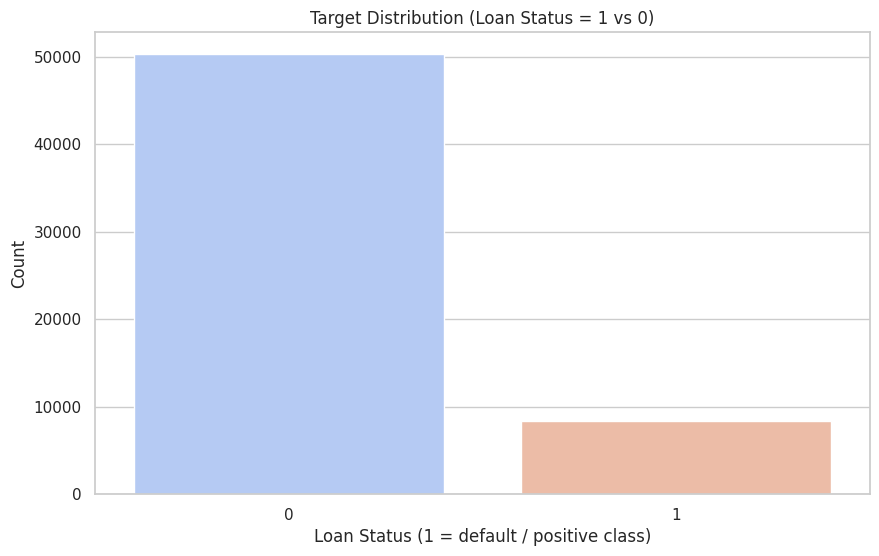

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


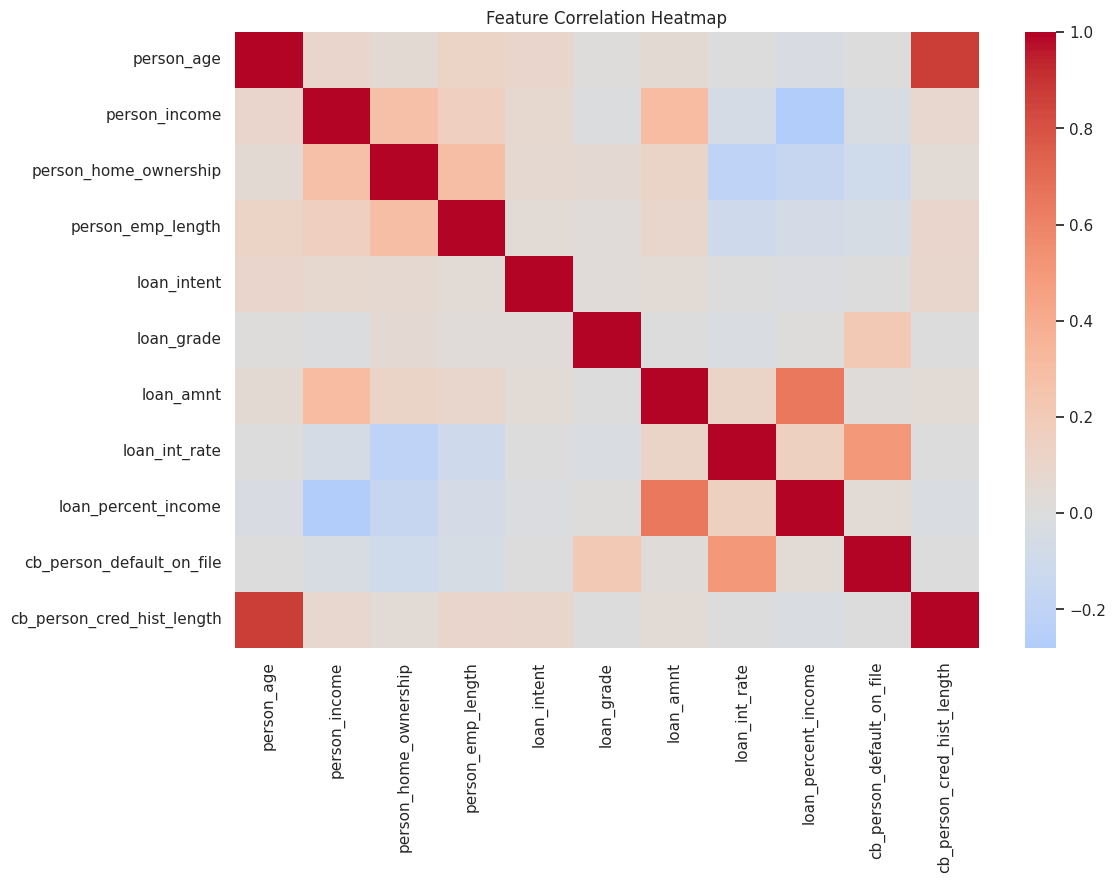

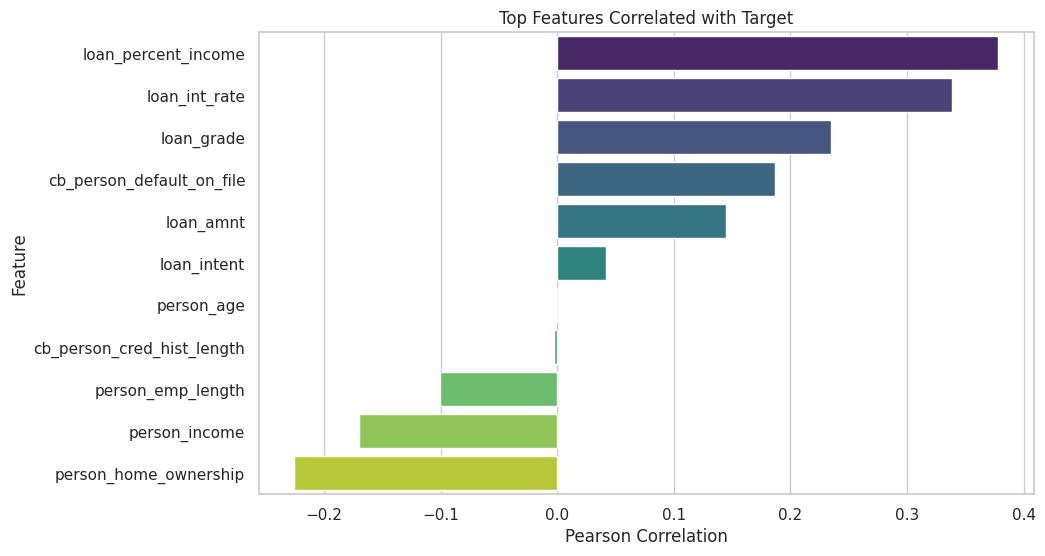

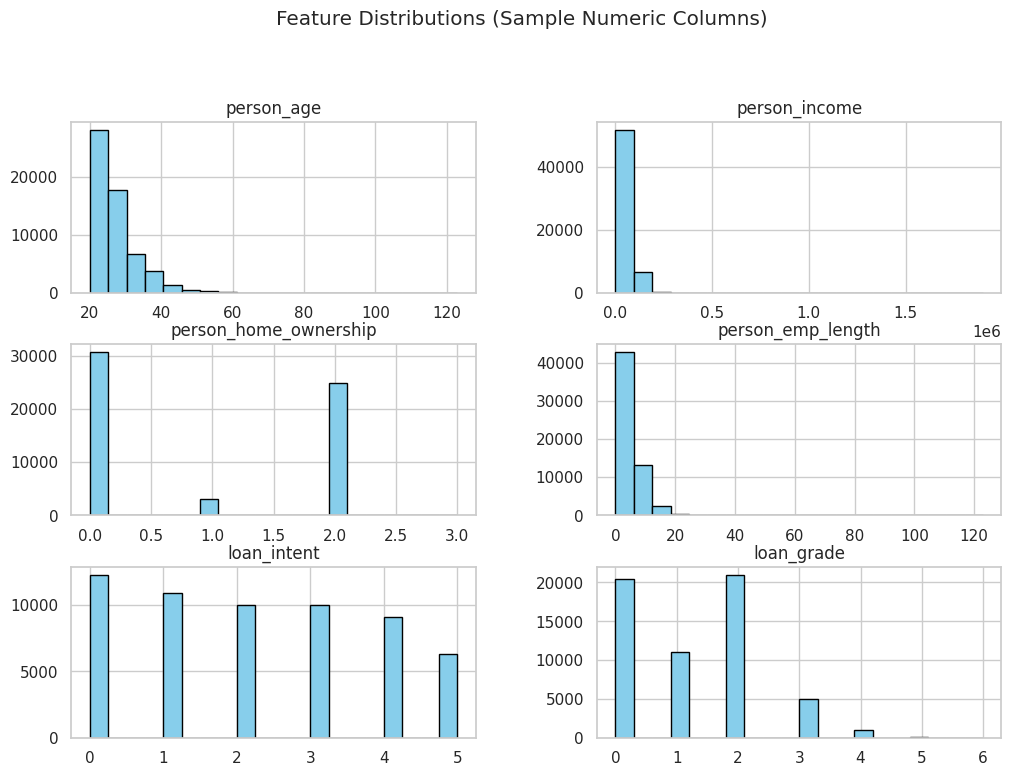


🚀 Training RandomForest Classifier...
Fold 1: AUC = 0.9346 | Accuracy = 0.9495
Fold 2: AUC = 0.9337 | Accuracy = 0.9503
Fold 3: AUC = 0.9380 | Accuracy = 0.9528

✅ Overall CV AUC: 0.9354


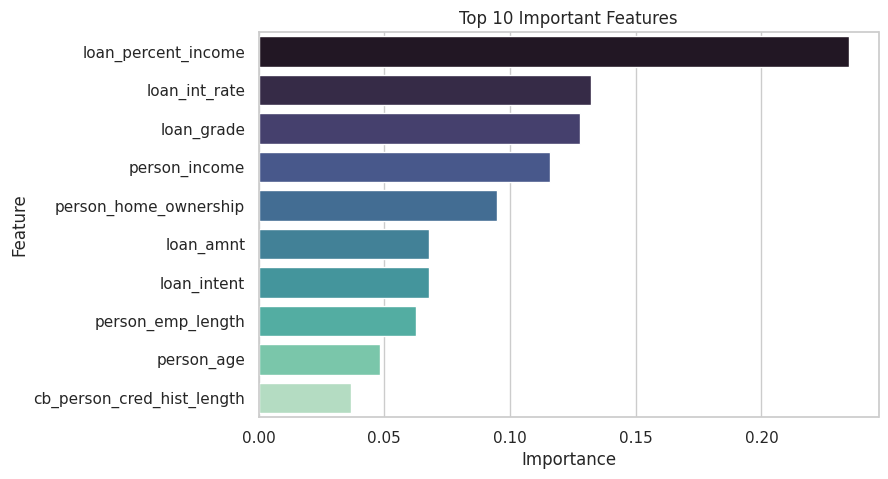


💾 Submission saved to /kaggle/working/submission.csv
      id  loan_status
0  58645     0.818333
1  58646     0.011667
2  58647     0.323333
3  58648     0.403333
4  58649     0.076667


In [2]:
# =============================================================
# 🧠 Loan Approval Prediction (Kaggle Playground Series - S4E10)
# Full Notebook: EDA + Correlation Heatmap + RandomForest Model
# =============================================================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

sns.set(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10,6)

# === 1️⃣ Load Dataset ===
DATA_DIR = "/kaggle/input/playground-series-s4e10"
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print("✅ Data loaded successfully!")
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

# === 2️⃣ Identify ID and Target Columns ===
id_col = "id"

# The correct target in this competition is `loan_status` (0/1) :contentReference[oaicite:1]{index=1}
target_col = "loan_status"

print(f"\n🪪 ID column: {id_col}")
print(f"🎯 Target column: {target_col}")

# Show unique values of target to verify
print("\nUnique values in target column before mapping:")
print(train[target_col].unique())

# === 3️⃣ Preprocessing ===
train_ids = train[id_col].copy()
test_ids = test[id_col].copy() if id_col in test.columns else test.iloc[:, 0].copy()

# If `loan_status` is already numeric 0/1, no mapping needed. But let's do robust mapping just in case:
target_mapping = {
    'Y': 1, 'Yes': 1, 'Approved': 1, '1': 1, 'True': 1,
    'N': 0, 'No': 0, 'Rejected': 0, '0': 0, 'False': 0
}

# Clean and map target
train[target_col] = train[target_col].astype(str).str.strip()
y = pd.to_numeric(train[target_col].map(target_mapping), errors='coerce')

# If mapping failed for many rows, maybe loan_status is numeric already:
if y.isna().sum() > 0:
    print(f"⚠️ Warning: {y.isna().sum()} unknown target values dropped.")
    valid_idx = y.notna()
    y = y[valid_idx].reset_index(drop=True)
    train = train.loc[valid_idx].reset_index(drop=True)

# Drop ID and target from features
X = train.drop(columns=[id_col, target_col])
X_test = test.drop(columns=[id_col]) if id_col in test.columns else test.drop(columns=[test.columns[0]])

# Handle categorical + missing values
for df in [X, X_test]:
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].fillna("Missing").astype(str)
            df[col], _ = pd.factorize(df[col])
        else:
            df[col] = df[col].fillna(df[col].median())

print("\n✅ Preprocessing complete!")
print(f"Number of training samples: {X.shape[0]}, Test samples: {X_test.shape[0]}")

# === 4️⃣ EDA (Exploratory Data Analysis) ===

# Target distribution
plt.figure()
sns.countplot(x=y.astype(int), palette="coolwarm")
plt.title("Target Distribution (Loan Status = 1 vs 0)")
plt.xlabel("Loan Status (1 = default / positive class)")
plt.ylabel("Count")
plt.show()

# Missing values in original train
missing = train.isnull().sum().sort_values(ascending=False)
if missing.iloc[0] > 0:
    plt.figure(figsize=(12,4))
    sns.barplot(x=missing.index[:15], y=missing.values[:15], color="salmon")
    plt.xticks(rotation=90)
    plt.title("Top Missing Values in Train Data")
    plt.show()

# Correlation heatmap among features
plt.figure(figsize=(12,8))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

# Correlation of features with target (numeric features only)
X_numeric = X.apply(pd.to_numeric, errors='coerce')
corr_with_target = X_numeric.corrwith(y, method='pearson').dropna().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=corr_with_target.values[:15], y=corr_with_target.index[:15], palette="viridis")
plt.title("Top Features Correlated with Target")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.show()

# Feature distributions (first few numeric features)
num_cols = X_numeric.columns[:6]
X_numeric[num_cols].hist(bins=20, figsize=(12,8), color="skyblue", edgecolor="black")
plt.suptitle("Feature Distributions (Sample Numeric Columns)", y=1.02)
plt.show()

# === 5️⃣ Model Training (RandomForest + CV) ===
print("\n🚀 Training RandomForest Classifier...")

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    model = RandomForestClassifier(n_estimators=200, random_state=fold, n_jobs=-1)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    oof[val_idx] = model.predict_proba(X.iloc[val_idx])[:,1]
    test_preds += model.predict_proba(X_test)[:,1] / skf.n_splits
    
    auc = roc_auc_score(y.iloc[val_idx], oof[val_idx])
    acc = accuracy_score(y.iloc[val_idx], (oof[val_idx] > 0.5).astype(int))
    print(f"Fold {fold}: AUC = {auc:.4f} | Accuracy = {acc:.4f}")

print(f"\n✅ Overall CV AUC: {roc_auc_score(y, oof):.4f}")

# Feature importance plot
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.head(10), y=importances.head(10).index, palette="mako")
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# === 6️⃣ Create Submission ===
# Decide output format based on sample submission
if sample_sub.shape[1] == 2 and sample_sub.iloc[:,1].dtype == object:
    # sample wants categorical output (Y/N)
    preds_label = np.where(test_preds > 0.5, 'Y', 'N')
    submission = pd.DataFrame({id_col: test_ids, sample_sub.columns[1]: preds_label})
else:
    # sample expects probability
    out_col = sample_sub.columns[1] if sample_sub.shape[1] > 1 else "loan_status"
    submission = pd.DataFrame({id_col: test_ids, out_col: test_preds})

submission.to_csv("/kaggle/working/submission.csv", index=False)
print("\n💾 Submission saved to /kaggle/working/submission.csv")
print(submission.head())
